# Preprocessing — Cartes spatiales SWI

Ce notebook transforme la base brute `jointure_meteo_swi_argile_nearest.gpkg`
en tenseur de cartes spatiales pret a l'emploi pour les notebooks d'entrainement.

**Sortie** : `data/maps/` contenant :
- `swi_maps.npy` — cartes SWI physiques `(T, H_crop, W_crop)`
- `swi_padded.npy` — cartes normalisees + paddees `(T, H_pad, W_pad)`
- `mask_padded.npy` — masque France `(H_pad, W_pad)`
- `metadata.json` — dimensions, stats mensuelles, dates


## 1. Imports et chargement

In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
import json, gc
from pathlib import Path
import matplotlib.pyplot as plt

OUT_DIR = Path('data/maps')
OUT_DIR.mkdir(parents=True, exist_ok=True)

gdf = gpd.read_file('data/processed/jointure_meteo_swi_argile_nearest.gpkg')
cols_f = gdf.select_dtypes('float64').columns
gdf[cols_f] = gdf[cols_f].astype('float32')
print(f'{len(gdf):,} lignes  |  {gdf["NUMERO"].nunique():,} points spatiaux')

7,005,180 lignes  |  8,981 points spatiaux


## 2. Grille spatiale (arrondi au pas SAFRAN 8000 m)

In [2]:
STEP = 8000

# On utilise les coordonnees geometry (CRS defini dans le GeoDataFrame)
# plutot que LAMBX/LAMBY dont le CRS est ambigu.
# Le pas theorique de la grille SAFRAN est 8000 m — on arrondit pour aligner.
gx = (gdf.geometry.x / STEP).round().astype(int) * STEP   # axe E-O
gy = (gdf.geometry.y / STEP).round().astype(int) * STEP   # axe S-N

unique_x = np.sort(gx.unique()).astype(np.int64)
unique_y = np.sort(gy.unique()).astype(np.int64)
x_to_col = {int(v): i for i, v in enumerate(unique_x)}
y_to_row  = {int(v): i for i, v in enumerate(unique_y)}
H_full, W_full = len(unique_y), len(unique_x)
print(f'CRS : {gdf.crs}')
print(f'Grille complete : {H_full} x {W_full}')

CRS : EPSG:27572
Grille complete : 133 x 131


In [3]:
dates_all   = np.sort(gdf['DATE'].unique())
T           = len(dates_all)
date_to_idx = {d: i for i, d in enumerate(dates_all)}
months_arr  = pd.DatetimeIndex(dates_all).month.values.astype(np.int32)
years_arr   = pd.DatetimeIndex(dates_all).year.values.astype(np.int32)

col_idx  = gx.map(x_to_col).values.astype(np.int32)
row_idx  = gy.map(y_to_row).values.astype(np.int32)
t_idx    = gdf['DATE'].map(date_to_idx).values.astype(np.int32)
swi_vals = gdf['SWI_UNIF_MENS'].values.astype(np.float32)

swi_full = np.full((T, H_full, W_full), np.nan, dtype=np.float32)
swi_full[t_idx, row_idx, col_idx] = swi_vals
gc.collect()
print(f'swi_full : {swi_full.shape}  ({swi_full.nbytes/1e6:.0f} MB)')

swi_full : (780, 133, 131)  (54 MB)


## 3. Tenseur SWI complet puis **crop au bounding box France**

On remplit d'abord la grille complete, puis on **rogne au rectangle minimal**
contenant tous les pixels France — cela reduit significativement le padding ulterieur.

In [4]:
# Bounding box des pixels France (masque)
land_full = np.isfinite(swi_full).any(axis=0)   # (H_full, W_full)
rows_ok = np.where(land_full.any(axis=1))[0]
cols_ok = np.where(land_full.any(axis=0))[0]
r0, r1 = int(rows_ok[0]), int(rows_ok[-1]) + 1
c0, c1 = int(cols_ok[0]), int(cols_ok[-1]) + 1

# Crop
swi_maps  = swi_full[:, r0:r1, c0:c1].copy()
land_mask = land_full[r0:r1, c0:c1]
del swi_full; gc.collect()

H, W = swi_maps.shape[1], swi_maps.shape[2]
print(f'Grille complete : {H_full} x {W_full}')
print(f'Bounding box France : {H} x {W}  (crop [{r0}:{r1}, {c0}:{c1}])')
print(f'Reduction : {(1 - H*W/(H_full*W_full))*100:.0f}% de cellules en moins')

Grille complete : 133 x 131
Bounding box France : 133 x 131  (crop [0:133, 0:131])
Reduction : 0% de cellules en moins


## 4. Normalisation mensuelle + padding

In [5]:
# Stats mensuelles
monthly_stats = {}
for m in range(1, 13):
    vals = swi_maps[months_arr == m][:, land_mask]
    monthly_stats[m] = (float(np.nanmean(vals)), float(np.nanstd(vals)))

# Normalisation
swi_norm = np.full_like(swi_maps, np.nan)
for m in range(1, 13):
    idx_m = months_arr == m
    mu_m, sig_m = monthly_stats[m]
    swi_norm[idx_m] = (swi_maps[idx_m] - mu_m) / (sig_m + 1e-8)
swi_norm_filled = np.nan_to_num(swi_norm, nan=0.0).astype(np.float32)

In [6]:
# Padding au multiple de 8 le plus proche
H_pad = int(np.ceil(H / 8)) * 8
W_pad = int(np.ceil(W / 8)) * 8
pad_h, pad_w = H_pad - H, W_pad - W

swi_padded  = np.pad(swi_norm_filled, ((0,0),(0,pad_h),(0,pad_w)), constant_values=0.0)
mask_padded = np.pad(land_mask.astype(np.float32), ((0,pad_h),(0,pad_w)), constant_values=0.0)

print(f'Crop      : {H} x {W}')
print(f'Padde     : {H_pad} x {W_pad}  (pad_h={pad_h}, pad_w={pad_w})')
print(f'swi_padded : {swi_padded.shape}  ({swi_padded.nbytes/1e6:.0f} MB)')

Crop      : 133 x 131
Padde     : 136 x 136  (pad_h=3, pad_w=5)
swi_padded : (780, 136, 136)  (58 MB)


## 5. Sauvegarde

In [7]:
np.save(OUT_DIR / 'swi_maps.npy',    swi_maps)
np.save(OUT_DIR / 'swi_padded.npy',  swi_padded)
np.save(OUT_DIR / 'land_mask.npy',   land_mask)
np.save(OUT_DIR / 'mask_padded.npy', mask_padded)

meta = {
    'H': int(H), 'W': int(W), 'H_pad': int(H_pad), 'W_pad': int(W_pad),
    'H_full': int(H_full), 'W_full': int(W_full),
    'crop': {'r0':r0,'r1':r1,'c0':c0,'c1':c1},
    'STEP': STEP, 'T': int(T),
    'dates': [str(d) for d in dates_all],
    'months': months_arr.tolist(),
    'years':  years_arr.tolist(),
    'monthly_stats': {str(k): list(v) for k, v in monthly_stats.items()},
}
with open(OUT_DIR / 'metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Sauvegarde terminee dans', OUT_DIR)
for p in sorted(OUT_DIR.iterdir()):
    print(f'  {p.name:<25} {p.stat().st_size/1e6:.1f} MB')

Sauvegarde terminee dans data\maps
  land_mask.npy             0.0 MB
  mask_padded.npy           0.1 MB
  metadata.json             0.0 MB
  swi_maps.npy              54.4 MB
  swi_padded.npy            57.7 MB


## 6. ACP des cartes SWI — estimation de la dimension latente

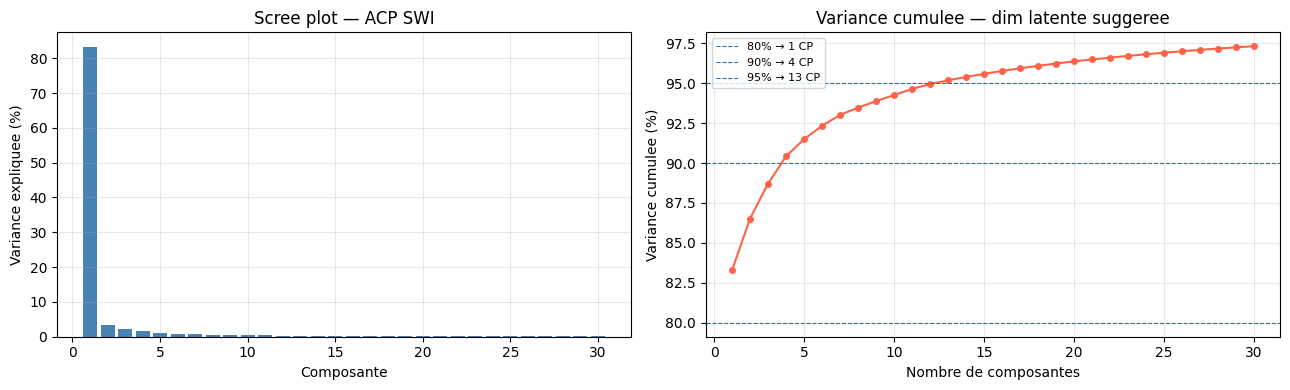

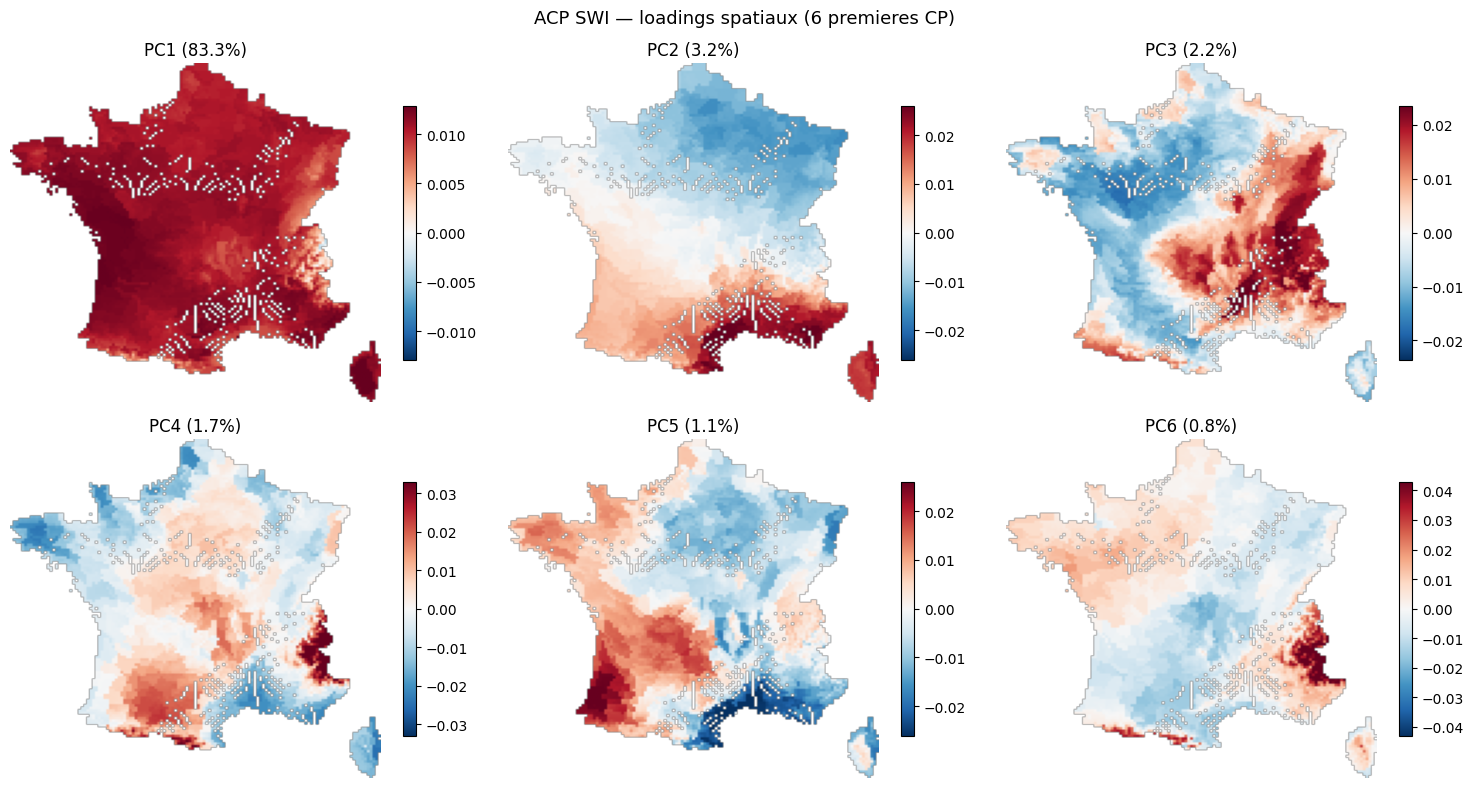

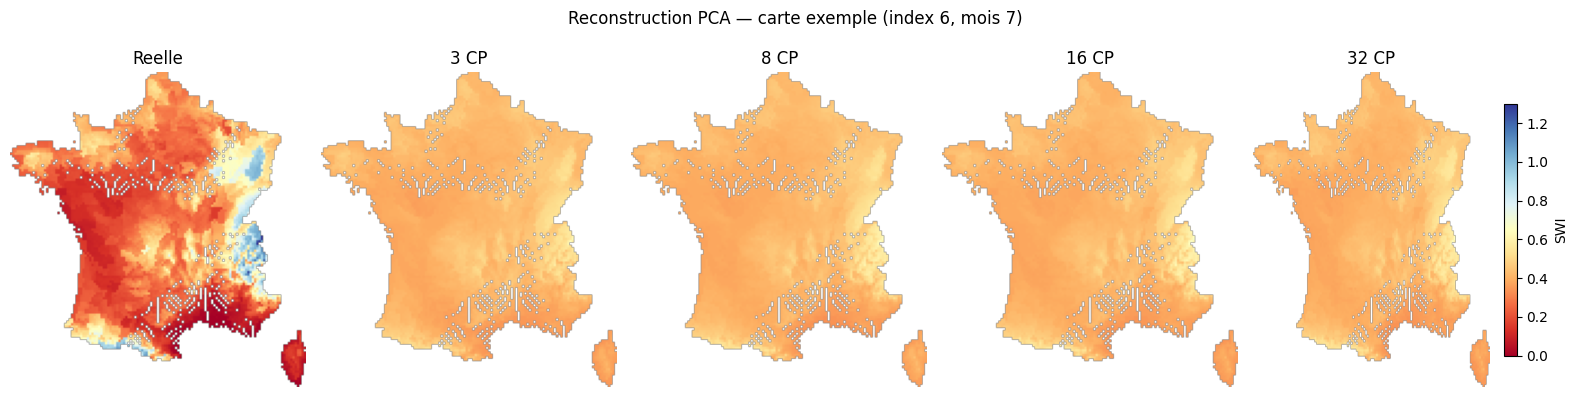

80% variance → 1 composantes  (LATENT_DIM suggere >= 1)
90% variance → 4 composantes  (LATENT_DIM suggere >= 4)
95% variance → 13 composantes  (LATENT_DIM suggere >= 13)


In [8]:
from sklearn.decomposition import PCA

# --- Matrice (T x n_pixels France) ---
X = swi_maps[:, land_mask]                     # (780, ~9000)
X = np.nan_to_num(X, nan=0.0).astype(np.float32)

N_COMP = 30
pca    = PCA(n_components=N_COMP)
scores = pca.fit_transform(X)                  # (T, 30)
comps  = pca.components_                       # (30, n_pixels)
var_exp = pca.explained_variance_ratio_

# --- 1. Scree plot + variance cumulee ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, N_COMP+1), var_exp * 100, color='steelblue')
axes[0].set(xlabel='Composante', ylabel='Variance expliquee (%)',
            title='Scree plot — ACP SWI')
axes[0].grid(True, alpha=0.3)

cumvar = np.cumsum(var_exp) * 100
axes[1].plot(range(1, N_COMP+1), cumvar, marker='o', ms=4, color='tomato')
for thr in [80, 90, 95]:
    n_thr = np.searchsorted(cumvar, thr) + 1
    axes[1].axhline(thr, ls='--', lw=0.8, label=f'{thr}% → {n_thr} CP')
axes[1].set(xlabel='Nombre de composantes', ylabel='Variance cumulee (%)',
            title='Variance cumulee — dim latente suggeree')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# --- 2. Cartes spatiales des 6 premieres CP (loadings) ---
cmap_div = plt.cm.RdBu_r
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('ACP SWI — loadings spatiaux (6 premieres CP)', fontsize=13)
for i, ax in enumerate(axes.flat):
    loading = np.full(land_mask.shape, np.nan)
    loading[land_mask] = comps[i]
    vmax = np.nanpercentile(np.abs(loading), 99)
    im = ax.imshow(loading, cmap=cmap_div, origin='lower',
                   vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_title(f'PC{i+1} ({var_exp[i]*100:.1f}%)'); ax.axis('off')
    plt.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout(); plt.show()

# --- 3. Reconstruction par K composantes — comparaison avec cartes reelles ---
K_LIST = [3, 8, 16, 32]
idx_ex = np.where(months_arr == 7)[0][0]      # exemple : premier juillet

fig, axes = plt.subplots(1, len(K_LIST)+1, figsize=(16, 4))
fig.suptitle(f'Reconstruction PCA — carte exemple (index {idx_ex}, mois {months_arr[idx_ex]})',
             fontsize=12)
cmap_swi = plt.cm.RdYlBu
vmin, vmax_swi = 0, 1.3

# Carte reelle
real = swi_maps[idx_ex].copy(); real[~land_mask] = np.nan
im = axes[0].imshow(real, cmap=cmap_swi, origin='lower', vmin=vmin, vmax=vmax_swi, aspect='auto')
axes[0].set_title('Reelle'); axes[0].axis('off')

for j, k in enumerate(K_LIST, 1):
    recon_pixels = pca.mean_ + scores[idx_ex, :k] @ comps[:k]
    recon = np.full(land_mask.shape, np.nan)
    mu_m, sig_m = monthly_stats[months_arr[idx_ex]]
    recon[land_mask] = recon_pixels * sig_m + mu_m
    axes[j].imshow(recon, cmap=cmap_swi, origin='lower', vmin=vmin, vmax=vmax_swi, aspect='auto')
    axes[j].set_title(f'{k} CP'); axes[j].axis('off')

fig.colorbar(im, ax=axes[-1], label='SWI', shrink=0.8)
plt.tight_layout(); plt.show()

# --- Resume ---
for thr in [80, 90, 95]:
    n_thr = int(np.searchsorted(cumvar, thr)) + 1
    print(f'{thr}% variance → {n_thr} composantes  (LATENT_DIM suggere >= {n_thr})')